In [1]:
!python kernelspec list

python: can't open file '/workspace/TA/Notebooks/kernelspec': [Errno 2] No such file or directory


In [2]:
!jupyter kernelspec uninstall ta_env -f 

Couldn't find kernel spec(s): ta_env


In [7]:
!conda remove --name ta_env --all -y

2 channel Terms of Service accepted

EnvironmentLocationNotFound: Not a conda environment: /home/kel02/miniconda/envs/ta_env



In [4]:
!df -h /workspace

Filesystem      Size  Used Avail Use% Mounted on
/dev/md127       28T   12T   15T  46% /workspace


In [3]:
# Jalankan sel ini untuk menginstal semua kebutuhan library di kernel ta_313
%pip install numpy pandas matplotlib seaborn
%pip install tensorflow[and-cuda]

Note: you may need to restart the kernel to use updated packages.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.4/572.4 MB 21.2 MB/s  0:00:31m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 4.8 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 7.5 MB/s  0:00:00m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 8.9 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 581.2/581.2 MB 20.7 MB/s  0:00:32m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 12.1 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.5/40.5 MB 12.6 MB/s  0:00:03 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.6/89.6 MB 18.3 MB/s  0:00:04m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 24.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 799.1/799.1 MB 25.4 MB/s  0:00:37m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.9/200.9 MB 26.8 MB/

In [1]:
# %% SECTION 1: Setup & GPU Configuration
print("\n" + "="*80)
print("SECTION 1: SETUP & GPU CONFIGURATION")
print("="*80)

import os, sys, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
warnings.filterwarnings('ignore')

# Konfigurasi environment untuk GPU B200 Blackwell
os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'
os.environ['NVIDIA_TF32_OVERRIDE'] = '0'
os.environ['TF_XLA_FLAGS'] = '--tf_xla_auto_jit=0'
os.environ['XLA_FLAGS'] = '--xla_gpu_enable_triton_gemm=false'

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Set seed untuk reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Konfigurasi alokasi dinamis memori GPU
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("✓ GPU B200 terdeteksi dan dikonfigurasi untuk Murni CNN.")
    except RuntimeError as e:
        print("Gagal mengonfigurasi memory growth:", e)

# Definisi path dataset
BASE_PATH = '/workspace/TA/Dataset'  
TRAIN_PATH = os.path.join(BASE_PATH, 'train')
VALID_PATH = os.path.join(BASE_PATH, 'valid')
TEST_PATH = os.path.join(BASE_PATH, 'test')

print(f"\n✓ Path Dataset:")
print(f"   TRAIN: {TRAIN_PATH} | EXISTS: {os.path.exists(TRAIN_PATH)}")
print(f"   VALID: {VALID_PATH} | EXISTS: {os.path.exists(VALID_PATH)}")
print(f"   TEST:  {TEST_PATH} | EXISTS: {os.path.exists(TEST_PATH)}")

# Konfigurasi model
CONFIG = {
    'img_height': 224,
    'img_width': 224,
    'img_channels': 3,
    'num_classes': 4,
    'batch_size': 128,       
    'epochs': 100,
    'learning_rate': 0.001,
    'dropout_rate': 0.5
}

print(f"\n✓ Konfigurasi:")
for key, value in CONFIG.items():
    print(f"   {key}: {value}")

# Class mapping untuk 4 kategori
CLASS_MAPPING = {0: 'Sitting', 1: 'Walking', 2: 'squatting', 3: 'standing'}
print(f"\n✓ TensorFlow version: {tf.__version__}")


SECTION 1: SETUP & GPU CONFIGURATION


I0000 00:00:1783140294.549416  245055 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1783140294.594072  245055 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1783140295.276685  245055 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.



✓ Path Dataset:
   TRAIN: /workspace/TA/Dataset/train | EXISTS: True
   VALID: /workspace/TA/Dataset/valid | EXISTS: True
   TEST:  /workspace/TA/Dataset/test | EXISTS: True

✓ Konfigurasi:
   img_height: 224
   img_width: 224
   img_channels: 3
   num_classes: 4
   batch_size: 128
   epochs: 100
   learning_rate: 0.001
   dropout_rate: 0.5

✓ TensorFlow version: 2.21.0


W0000 00:00:1783140296.200587  245328 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1783140296.419732  245055 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [2]:
# %% SECTION 2: COCO Dataset Processing
print("\n" + "="*80)
print("SECTION 2: COCO DATASET PROCESSING")
print("="*80)

from collections import Counter

def load_coco_annotations(json_path):
    """Load COCO format annotations dari JSON file"""
    with open(json_path, 'r') as f:
        coco_data = json.load(f)
    print(f"    ✓ Loaded: {os.path.basename(json_path)}")
    return coco_data

def parse_coco_dataset(coco_data, image_dir, split_name=""):
    """Parse COCO annotations dan return image paths dengan labels"""
    image_paths, labels = [], []
    
    print(f"\n   Parsing {split_name}:")
    
    # Membuat mapping dari image_id ke category (convert 1-indexed ke 0-indexed)
    image_id_to_category = {}
    for annotation in coco_data.get('annotations', []):
        image_id_to_category[annotation['image_id']] = annotation['category_id'] - 1

    # Iterasi images dan match dengan annotations
    images_found = 0
    for image in coco_data.get('images', []):
        image_id = image['id']
        if image_id not in image_id_to_category:
            continue
        
        image_path = os.path.join(image_dir, image['file_name'])
        if os.path.exists(image_path):
            image_paths.append(image_path)
            labels.append(image_id_to_category[image_id])
            images_found += 1

    print(f"      ✓ Found & loaded: {images_found} images")
    return image_paths, labels

# Load annotations dari ketiga split dataset
print("\nLoading COCO Annotations...\n")
train_images, train_labels = [], []
valid_images, valid_labels = [], []
test_images, test_labels = [], []

for file in os.listdir(TRAIN_PATH):
    if file.endswith('.json'):
        train_coco = load_coco_annotations(os.path.join(TRAIN_PATH, file))
        train_images, train_labels = parse_coco_dataset(train_coco, TRAIN_PATH, "TRAIN")
        break

for file in os.listdir(VALID_PATH):
    if file.endswith('.json'):
        valid_coco = load_coco_annotations(os.path.join(VALID_PATH, file))
        valid_images, valid_labels = parse_coco_dataset(valid_coco, VALID_PATH, "VALID")
        break

for file in os.listdir(TEST_PATH):
    if file.endswith('.json'):
        test_coco = load_coco_annotations(os.path.join(TEST_PATH, file))
        test_images, test_labels = parse_coco_dataset(test_coco, TEST_PATH, "TEST")
        break

print("\n" + "="*80)
print(f"✓ Dataset Summary:")
print(f"   Train: {len(train_images)} | Valid: {len(valid_images)} | Test: {len(test_images)}")

# Tampilkan distribusi kelas
print(f"\n✓ Class Distribution:")
for split_name, labels in [('Train', train_labels), ('Valid', valid_labels), ('Test', test_labels)]:
    if len(labels) > 0:
        print(f"\n   {split_name}:")
        counter = Counter(labels)
        for class_idx in range(4):
            count = counter.get(class_idx, 0)
            percentage = (count / len(labels) * 100) if len(labels) > 0 else 0
            print(f"      {CLASS_MAPPING[class_idx]}: {count} ({percentage:.1f}%)")


SECTION 2: COCO DATASET PROCESSING

Loading COCO Annotations...

    ✓ Loaded: _annotations.coco.json

   Parsing TRAIN:
      ✓ Found & loaded: 3500 images
    ✓ Loaded: _annotations.coco.json

   Parsing VALID:
      ✓ Found & loaded: 748 images
    ✓ Loaded: _annotations.coco.json

   Parsing TEST:
      ✓ Found & loaded: 752 images

✓ Dataset Summary:
   Train: 3500 | Valid: 748 | Test: 752

✓ Class Distribution:

   Train:
      Sitting: 875 (25.0%)
      Walking: 875 (25.0%)
      squatting: 875 (25.0%)
      standing: 875 (25.0%)

   Valid:
      Sitting: 187 (25.0%)
      Walking: 187 (25.0%)
      squatting: 187 (25.0%)
      standing: 187 (25.0%)

   Test:
      Sitting: 188 (25.0%)
      Walking: 188 (25.0%)
      squatting: 188 (25.0%)
      standing: 188 (25.0%)


In [ ]:
# %% SECTION 3: DATA LOADING & PREPROCESSING
print("\n" + "="*80)
print("SECTION 3: DATA LOADING & PREPROCESSING")
print("="*80)

# Konversi paths ke Pandas DataFrame (string format untuk categorical mode keras)
train_df = pd.DataFrame({
    'filename': train_images, 
    'label': [str(lbl) for lbl in train_labels]
})

valid_df = pd.DataFrame({
    'filename': valid_images, 
    'label': [str(lbl) for lbl in valid_labels]
})

print(f"\n✓ DataFrame berhasil dibuat:")
print(f"   Train: {len(train_df)} baris")
print(f"   Valid: {len(valid_df)} baris")


SECTION 3: DATA LOADING & PREPROCESSING

✓ DataFrame berhasil dibuat:
   Train: 3500 baris
   Valid: 748 baris


In [5]:
# %% SECTION 4: DATA AUGMENTATION & DATA LOADERS
print("\n" + "="*80)
print("SECTION 4: DATA AUGMENTATION & DATA LOADERS")
print("="*80)

# Konfigurasi data augmentation untuk training (rotasi, shift, zoom, flip)
train_datagen = ImageDataGenerator(
    rescale=1./255,            # Normalisasi pixel [0,1]
    rotation_range=30,         # Random rotation ±30°
    width_shift_range=0.1,     # Random horizontal shift 10%
    height_shift_range=0.1,    # Random vertical shift 10%
    zoom_range=0.1,            # Random zoom 10%
    horizontal_flip=True,      # Random horizontal flip
    fill_mode='nearest'        # Fill strategy untuk augmented pixels
)

# Validasi: hanya rescale, tanpa augmentation
valid_datagen = ImageDataGenerator(rescale=1./255)

print("\nMembangun data loaders...")

# Data loader training dengan augmentation
train_ds_aug = train_datagen.flow_from_dataframe(
    dataframe=train_df, 
    x_col='filename', 
    y_col='label',
    target_size=(CONFIG['img_width'], CONFIG['img_height']),
    batch_size=CONFIG['batch_size'], 
    class_mode='categorical', 
    shuffle=True, 
    seed=42
)

# Data loader validasi tanpa augmentation
val_ds = valid_datagen.flow_from_dataframe(
    dataframe=valid_df, 
    x_col='filename', 
    y_col='label',
    target_size=(CONFIG['img_width'], CONFIG['img_height']),
    batch_size=CONFIG['batch_size'], 
    class_mode='categorical', 
    shuffle=False, 
    seed=42
)

# Alias agar konsisten dengan permintaan tuning
train_generator = train_ds_aug
valid_generator = val_ds

print("-" * 60)
print("✓ Data loaders berhasil dibuat:")
print(f"   Train batches: {len(train_ds_aug)}")
print(f"   Valid batches: {len(val_ds)}")
print("-" * 60)


SECTION 4: DATA AUGMENTATION & DATA LOADERS

Membangun data loaders...
Found 3500 validated image filenames belonging to 4 classes.
Found 748 validated image filenames belonging to 4 classes.
------------------------------------------------------------
✓ Data loaders berhasil dibuat:
   Train batches: 28
   Valid batches: 6
------------------------------------------------------------


In [6]:
# %% SECTION 5: CNN MODEL FACTORY
print("\n" + "="*80)
print("SECTION 5: CNN MODEL FACTORY")
print("="*80)

MODEL_SAVE_DIR = "/workspace/TA/best_model/Tuning"
TUNING_RESULTS_CSV = os.path.join(MODEL_SAVE_DIR, "tuning_results.csv")
TUNING_HISTORY_DIR = os.path.join(MODEL_SAVE_DIR, "tuning_histories")
BEST_TUNED_MODEL_PATH = os.path.join(MODEL_SAVE_DIR, "best_cnn_tuned.keras")

def build_cnn_model(architecture, learning_rate, optimizer_name, dropout_rate):
    """Build CNN model untuk Architecture A atau B dengan optimizer pilihan."""
    architecture = str(architecture).upper()
    optimizer_name = str(optimizer_name).lower()

    if architecture not in {"A", "B"}:
        raise ValueError("architecture harus 'A' atau 'B'.")

    if optimizer_name == "adam":
        optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    elif optimizer_name == "adagrad":
        optimizer = keras.optimizers.Adagrad(learning_rate=learning_rate)
    else:
        raise ValueError("optimizer_name harus 'Adam' atau 'Adagrad'.")

    model = models.Sequential(name=f"cnn_arch_{architecture.lower()}_{optimizer_name}")
    model.add(layers.Input(shape=(CONFIG["img_height"], CONFIG["img_width"], CONFIG["img_channels"])))

    block_specs = [
        (32, 0.2),
        (64, 0.3),
        (128, 0.4),
    ]
    if architecture == "B":
        block_specs.append((256, 0.5))

    for filters, block_dropout in block_specs:
        model.add(layers.Conv2D(filters, (3, 3), activation="relu"))
        model.add(layers.BatchNormalization())
        model.add(layers.Conv2D(filters, (3, 3), activation="relu"))
        model.add(layers.BatchNormalization())
        model.add(layers.MaxPooling2D((2, 2)))
        model.add(layers.Dropout(block_dropout))

    model.add(layers.Flatten(name="flatten_features"))
    model.add(layers.Dense(256, activation="relu"))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(dropout_rate))
    model.add(layers.Dense(CONFIG["num_classes"], activation="softmax"))

    model.compile(
        optimizer=optimizer,
        loss="categorical_crossentropy",
        metrics=[
            "accuracy",
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
        ],
        jit_compile=False,
    )

    return model

print("✓ build_cnn_model siap digunakan untuk Architecture A dan B.")


SECTION 5: CNN MODEL FACTORY
✓ build_cnn_model siap digunakan untuk Architecture A dan B.



SECTION 6: HYPERPARAMETER TUNING

--------------------------------------------------------------------------------
[1/16] Training config:
   Architecture   : A
   Learning Rate  : 0.001
   Optimizer      : Adam
   Dropout Rate   : 0.5
   Best train acc  : 0.8214
   Best val acc    : 0.7366
   Best val loss   : 0.6637
   Gap train-val   : 0.0848
   Epochs run      : 33
   Training time   : 1223.64 sec
   History saved   : /workspace/TA/best_model/Tuning/tuning_histories/history_arch_A_lr_0p001_opt_adam_dropout_0p5.csv

--------------------------------------------------------------------------------
[2/16] Training config:
   Architecture   : A
   Learning Rate  : 0.001
   Optimizer      : Adam
   Dropout Rate   : 0.7
   Best train acc  : 0.6863
   Best val acc    : 0.4398
   Best val loss   : 1.4208
   Gap train-val   : 0.2464
   Epochs run      : 7
   Training time   : 264.05 sec
   History saved   : /workspace/TA/best_model/Tuning/tuning_histories/history_arch_A_lr_0p001_opt_adam_dr

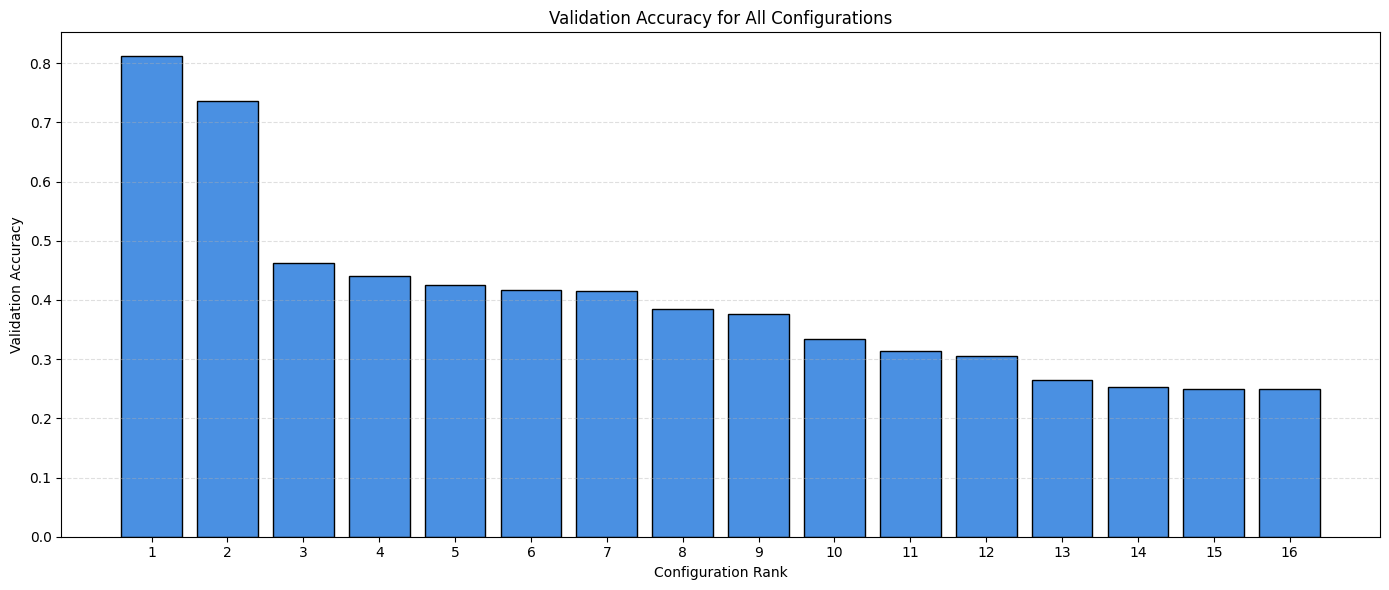

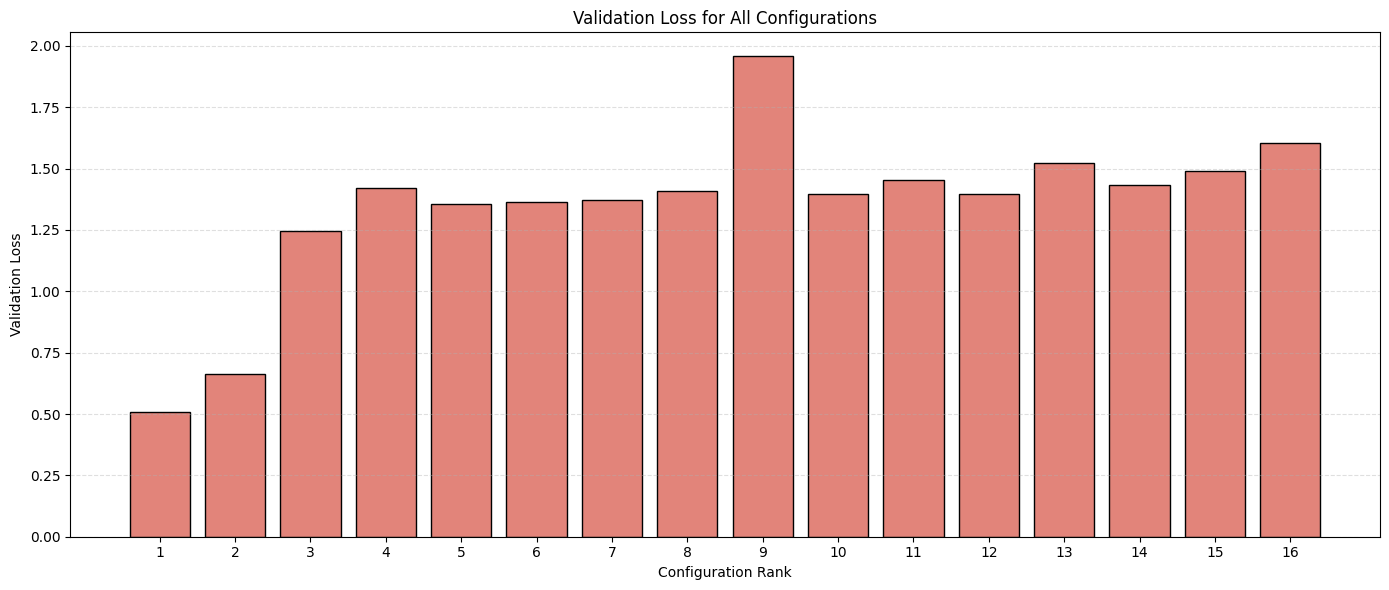

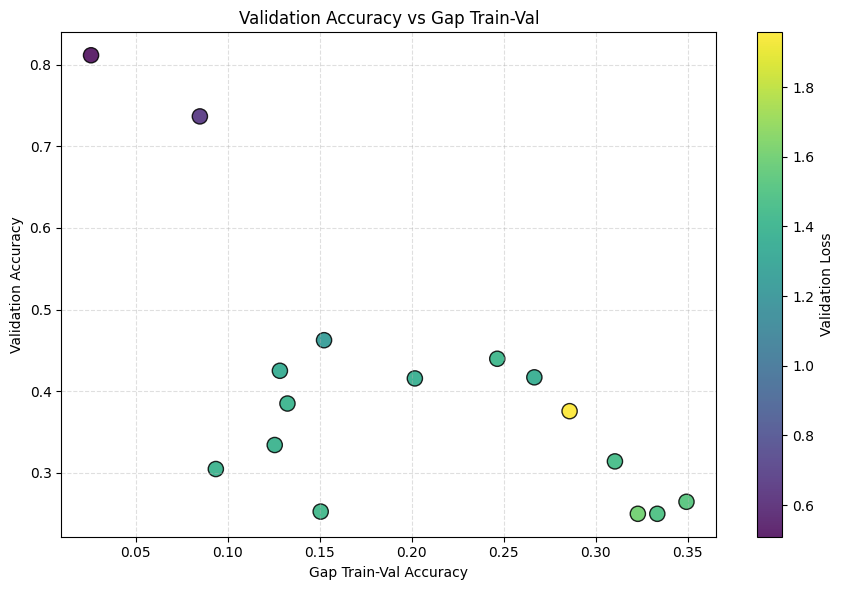

In [6]:
# %% SECTION 6: HYPERPARAMETER TUNING
print("\n" + "="*80)
print("SECTION 6: HYPERPARAMETER TUNING")
print("="*80)

import time
from itertools import product

architecture_options = ["A", "B"]
learning_rate_options = [0.001, 0.0001]
optimizer_options = ["Adam", "Adagrad"]
dropout_options = [0.5, 0.7]

total_configs = len(architecture_options) * len(learning_rate_options) * len(optimizer_options) * len(dropout_options)
tuning_records = []
tuning_history_map = {}

os.makedirs(MODEL_SAVE_DIR, exist_ok=True)
os.makedirs(TUNING_HISTORY_DIR, exist_ok=True)

config_counter = 0

for architecture, learning_rate, optimizer_name, dropout_rate in product(architecture_options, learning_rate_options, optimizer_options, dropout_options):
    config_counter += 1
    print("\n" + "-" * 80)
    print(f"[{config_counter}/{total_configs}] Training config:")
    print(f"   Architecture   : {architecture}")
    print(f"   Learning Rate  : {learning_rate}")
    print(f"   Optimizer      : {optimizer_name}")
    print(f"   Dropout Rate   : {dropout_rate}")

    tf.keras.backend.clear_session()
    model = build_cnn_model(architecture, learning_rate, optimizer_name, dropout_rate)

    tuning_early_stopping = EarlyStopping(
        monitor="val_loss",
        patience=6,
        restore_best_weights=True,
        verbose=0,
    )

    start_time = time.perf_counter()
    history = model.fit(
        train_generator,
        validation_data=valid_generator,
        epochs=CONFIG["epochs"],
        callbacks=[tuning_early_stopping],
        verbose=0,
    )
    training_time = time.perf_counter() - start_time

    history_df = pd.DataFrame(history.history)
    lr_tag = str(learning_rate).replace(".", "p")
    dropout_tag = str(dropout_rate).replace(".", "p")
    history_file = os.path.join(
        TUNING_HISTORY_DIR,
        f"history_arch_{architecture}_lr_{lr_tag}_opt_{optimizer_name.lower()}_dropout_{dropout_tag}.csv",
    )
    history_df.to_csv(history_file, index=False)
    tuning_history_map[(architecture, learning_rate, optimizer_name, dropout_rate)] = history_df

    train_accuracy_series = history.history.get("accuracy", [])
    val_accuracy_series = history.history.get("val_accuracy", [])
    val_loss_series = history.history.get("val_loss", [])

    best_train_accuracy = float(np.max(train_accuracy_series)) if len(train_accuracy_series) else np.nan
    best_validation_accuracy = float(np.max(val_accuracy_series)) if len(val_accuracy_series) else np.nan
    best_validation_loss = float(np.min(val_loss_series)) if len(val_loss_series) else np.nan
    gap_train_val_accuracy = best_train_accuracy - best_validation_accuracy if pd.notna(best_train_accuracy) and pd.notna(best_validation_accuracy) else np.nan
    epochs_ran = len(history.history.get("loss", []))

    record = {
        "architecture": architecture,
        "learning_rate": learning_rate,
        "optimizer": optimizer_name,
        "dropout_rate": dropout_rate,
        "best_train_accuracy": best_train_accuracy,
        "best_validation_accuracy": best_validation_accuracy,
        "best_validation_loss": best_validation_loss,
        "gap_train_val_accuracy": gap_train_val_accuracy,
        "epochs_ran": epochs_ran,
        "training_time": training_time,
        "history_file": history_file,
        "config_label": f"Arch {architecture} | LR {learning_rate} | Opt {optimizer_name} | Drop {dropout_rate}",
    }
    tuning_records.append(record)

    print(f"   Best train acc  : {best_train_accuracy:.4f}")
    print(f"   Best val acc    : {best_validation_accuracy:.4f}")
    print(f"   Best val loss   : {best_validation_loss:.4f}")
    print(f"   Gap train-val   : {gap_train_val_accuracy:.4f}")
    print(f"   Epochs run      : {epochs_ran}")
    print(f"   Training time   : {training_time:.2f} sec")
    print(f"   History saved   : {history_file}")

tuning_results_df = pd.DataFrame(tuning_records)
ranked_tuning_df = tuning_results_df.sort_values(
    by=["best_validation_accuracy", "best_validation_loss", "gap_train_val_accuracy"],
    ascending=[False, True, True],
).reset_index(drop=True)
ranked_tuning_df.insert(0, "rank", np.arange(1, len(ranked_tuning_df) + 1))

ranked_tuning_df.to_csv(TUNING_RESULTS_CSV, index=False)

top10_tuning_df = ranked_tuning_df.head(10).copy()

print("\n" + "="*80)
print("TOP 10 KONFIGURASI TERBAIK")
print("="*80)
print(
    top10_tuning_df[[
        "rank",
        "architecture",
        "learning_rate",
        "optimizer",
        "dropout_rate",
        "best_train_accuracy",
        "best_validation_accuracy",
        "best_validation_loss",
        "gap_train_val_accuracy",
        "epochs_ran",
        "training_time",
    ]].to_string(index=False, float_format=lambda value: f"{value:.4f}")
 )

best_tuning_result = ranked_tuning_df.iloc[0]

print("\n" + "="*80)
print("KONFIGURASI TERBAIK OTOMATIS")
print("="*80)
print(f"Architecture terbaik   : {best_tuning_result['architecture']}")
print(f"Learning Rate terbaik  : {best_tuning_result['learning_rate']}")
print(f"Optimizer terbaik      : {best_tuning_result['optimizer']}")
print(f"Dropout terbaik        : {best_tuning_result['dropout_rate']}")
print(f"Validation Accuracy    : {best_tuning_result['best_validation_accuracy']:.4f}")
print(f"Validation Loss        : {best_tuning_result['best_validation_loss']:.4f}")
print(f"Gap Train-Val          : {best_tuning_result['gap_train_val_accuracy']:.4f} ({best_tuning_result['gap_train_val_accuracy'] * 100:.2f}%)")
print(f"Hasil tuning disimpan   : {TUNING_RESULTS_CSV}")

plot_df = ranked_tuning_df.copy()
plot_df["config_label_short"] = [f"{idx+1}" for idx in range(len(plot_df))]

plt.figure(figsize=(14, 6))
plt.bar(plot_df["config_label_short"], plot_df["best_validation_accuracy"], color="#4A90E2", edgecolor="black")
plt.xticks(rotation=0)
plt.ylabel("Validation Accuracy")
plt.xlabel("Configuration Rank")
plt.title("Validation Accuracy for All Configurations")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 6))
plt.bar(plot_df["config_label_short"], plot_df["best_validation_loss"], color="#E2847A", edgecolor="black")
plt.xticks(rotation=0)
plt.ylabel("Validation Loss")
plt.xlabel("Configuration Rank")
plt.title("Validation Loss for All Configurations")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 6))
scatter = plt.scatter(
    ranked_tuning_df["gap_train_val_accuracy"],
    ranked_tuning_df["best_validation_accuracy"],
    c=ranked_tuning_df["best_validation_loss"],
    cmap="viridis",
    s=120,
    edgecolors="black",
    alpha=0.85,
 )
plt.colorbar(scatter, label="Validation Loss")
plt.xlabel("Gap Train-Val Accuracy")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy vs Gap Train-Val")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

In [7]:
# %% SECTION 6B: TUNING RESULTS TABLE (LOAD FROM SAVED CSV IF NEEDED)
print("\n" + "="*80)
print("SECTION 6B: TUNING RESULTS TABLE")
print("="*80)

from IPython.display import display

# Jika kernel reset dan hasil Section 6 belum ada di memory, load dari CSV
if "ranked_tuning_df" not in globals() or ranked_tuning_df is None:
    if os.path.exists(TUNING_RESULTS_CSV):
        ranked_tuning_df = pd.read_csv(TUNING_RESULTS_CSV)
        print(f"\n✓ ranked_tuning_df di-load dari file: {TUNING_RESULTS_CSV}")
    else:
        raise FileNotFoundError(
            f"File hasil tuning tidak ditemukan: {TUNING_RESULTS_CSV}. "
            "Jalankan Section 6 sekali untuk membuat file hasil tuning."
        )

# Pastikan best_tuning_result tersedia untuk section berikutnya
best_tuning_result = ranked_tuning_df.sort_values(
    by=["best_validation_accuracy", "best_validation_loss", "gap_train_val_accuracy"],
    ascending=[False, True, True],
).iloc[0]

summary_columns = [
    "rank",
    "architecture",
    "learning_rate",
    "optimizer",
    "dropout_rate",
    "best_train_accuracy",
    "best_validation_accuracy",
    "best_validation_loss",
    "gap_train_val_accuracy",
    "epochs_ran",
    "training_time",
]

tuning_table_df = ranked_tuning_df[summary_columns].copy()
tuning_table_df["best_train_accuracy"] = tuning_table_df["best_train_accuracy"].round(4)
tuning_table_df["best_validation_accuracy"] = tuning_table_df["best_validation_accuracy"].round(4)
tuning_table_df["best_validation_loss"] = tuning_table_df["best_validation_loss"].round(4)
tuning_table_df["gap_train_val_accuracy"] = tuning_table_df["gap_train_val_accuracy"].round(4)
tuning_table_df["training_time"] = tuning_table_df["training_time"].round(2)

print("\n✓ Tabel hasil tuning keseluruhan:")
display(tuning_table_df)

best_hyperparameters_df = pd.DataFrame([
    {
        "architecture": best_tuning_result["architecture"],
        "learning_rate": best_tuning_result["learning_rate"],
        "optimizer": best_tuning_result["optimizer"],
        "dropout_rate": best_tuning_result["dropout_rate"],
        "best_validation_accuracy": round(float(best_tuning_result["best_validation_accuracy"]), 4),
        "best_validation_loss": round(float(best_tuning_result["best_validation_loss"]), 4),
        "gap_train_val_accuracy": round(float(best_tuning_result["gap_train_val_accuracy"]), 4),
    }
])

print("\n✓ Hyperparameter terbaik:")
display(best_hyperparameters_df)


SECTION 6B: TUNING RESULTS TABLE

✓ ranked_tuning_df di-load dari file: /workspace/TA/best_model/Tuning/tuning_results.csv

✓ Tabel hasil tuning keseluruhan:


,rank,architecture,learning_rate,optimizer,dropout_rate,best_train_accuracy,best_validation_accuracy,best_validation_loss,gap_train_val_accuracy,epochs_ran,training_time
0,1,B,0.0010,Adam,0.7,0.8371,0.8115,0.5090,0.0256,37,1376.84
1,2,A,0.0010,Adam,0.5,0.8214,0.7366,0.6637,0.0848,33,1223.64
2,3,B,0.0010,Adagrad,0.5,0.6149,0.4626,1.2437,0.1523,15,558.71
3,4,A,0.0010,Adam,0.7,0.6863,0.4398,1.4208,0.2464,7,264.05
4,5,B,0.0010,Adagrad,0.7,0.5534,0.4251,1.3563,0.1283,10,380.27
5,6,B,0.0010,Adam,0.5,0.6837,0.4171,1.3619,0.2666,7,266.93
6,7,A,0.0001,Adam,0.7,0.6174,0.4158,1.3703,0.2017,7,262.08
7,8,A,0.0001,Adagrad,0.5,0.5174,0.3850,1.4074,0.1324,7,262.62
8,9,A,0.0001,Adam,0.5,0.6614,0.3757,1.9572,0.2858,7,260.91
9,10,A,0.0001,Adagrad,0.7,0.4597,0.3342,1.3944,0.1255,7,259.46



✓ Hyperparameter terbaik:


,architecture,learning_rate,optimizer,dropout_rate,best_validation_accuracy,best_validation_loss,gap_train_val_accuracy
0,B,0.001,Adam,0.7,0.8115,0.509,0.0256
